# Mauritius Profiles Analysis

Time-series and input-data checks for the Mauritius baseline run.

This notebook is deliberately separate from `01_run_analysis.ipynb` so the main run analysis stays focused on network/cost outputs. It answers three questions:

- how solved load and generation move through the year;
- what wind and solar availability profiles were built before solving;
- which demand, weather, and capacity-limit inputs collaborators should know about.

The dispatch plots use **MWh per model period**. The current baseline solve uses 3-hour snapshots, so each plotted dispatch/load value is `MW × 3 h`.


## Sync Inputs From ARC

If the resources are not present locally, sync the lightweight input/profile artifacts from ARC:

```bash
rsync -az --relative -e "ssh -S $HOME/.ssh/arc-oxford-codex.sock -o BatchMode=yes"   arc-oxford:/data/engs-df-green-ammonia/engs2523/pypsa-earth-mauritius-kestrel/pypsa-earth/./resources/mauritius-year-1/demand_profiles.csv   arc-oxford:/data/engs-df-green-ammonia/engs2523/pypsa-earth-mauritius-kestrel/pypsa-earth/./resources/mauritius-year-1/renewable_profiles/   arc-oxford:/data/engs-df-green-ammonia/engs2523/pypsa-earth-mauritius-kestrel/pypsa-earth/./resources/mauritius-year-1/base_network/   arc-oxford:/data/engs-df-green-ammonia/engs2523/pypsa-earth-mauritius-kestrel/pypsa-earth/./resources/mauritius-year-1/bus_regions/   arc-oxford:/data/engs-df-green-ammonia/engs2523/pypsa-earth-mauritius-kestrel/pypsa-earth/./resources/mauritius-year-1/shapes/   pypsa-earth/
```


In [1]:
from pathlib import Path
import copy
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import xarray as xr
import yaml

warnings.filterwarnings("ignore", category=FutureWarning)


def _repo_root():
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "notebooks").exists() and (candidate / "pypsa-earth").exists():
            return candidate
    return Path("..").resolve()


def _deep_update(base, override):
    result = copy.deepcopy(base)
    for key, value in (override or {}).items():
        if isinstance(value, dict) and isinstance(result.get(key), dict):
            result[key] = _deep_update(result[key], value)
        else:
            result[key] = value
    return result


REPO_ROOT = _repo_root()
RUN_NAME = "mauritius-year-1"
PYPSA_DIR = REPO_ROOT / "pypsa-earth"
RESULT_NETWORK = REPO_ROOT / "results" / RUN_NAME / "networks" / "elec_s_12flex_ec_lcopt_3h.nc"
LOCAL_NETWORK = PYPSA_DIR / "networks" / RUN_NAME / "elec_s_12flex_ec_lcopt_3h.nc"
NETWORK_PATH = RESULT_NETWORK if RESULT_NETWORK.exists() else LOCAL_NETWORK
RESOURCES = PYPSA_DIR / "resources" / RUN_NAME
PROFILE_DIR = RESOURCES / "renewable_profiles"
DEMAND_PATH = RESOURCES / "demand_profiles.csv"
SCENARIO_CONFIG = PYPSA_DIR / "configs" / "scenarios" / "config.mauritius-year-1.yaml"
DEFAULT_CONFIG = PYPSA_DIR / "config.default.yaml"
DEMAND_LOG = PYPSA_DIR / "logs" / RUN_NAME / "build_demand_profiles.log"

if not NETWORK_PATH.exists():
    raise FileNotFoundError(f"Solved network not found: {NETWORK_PATH}")

with DEFAULT_CONFIG.open() as fh:
    default_config = yaml.safe_load(fh)
with SCENARIO_CONFIG.open() as fh:
    scenario_config = yaml.safe_load(fh)
config = _deep_update(default_config, scenario_config)

n = pypsa.Network(str(NETWORK_PATH))

TECH_COLORS = {
    "solar": "#f9d71c",
    "onwind": "#235ebc",
    "offwind-ac": "#6895dd",
    "offwind-dc": "#74c6f2",
    "ror": "#78d4cf",
    "hydro": "#08ad97",
    "OCGT": "#e05b5b",
    "CCGT": "#d35050",
    "coal": "#545454",
    "lignite": "#826a4a",
    "nuclear": "#ff8c00",
    "oil": "#2a2a2a",
    "biomass": "#baa741",
    "load shedding": "#ff0000",
}


def tech_color(carrier):
    return TECH_COLORS.get(carrier, "#888888")


def styled_table(df, fmt=None, **kwargs):
    try:
        styler = df.style
        if fmt is not None:
            styler = styler.format(fmt, **kwargs)
        return styler
    except Exception:
        return df


snapshot_weights = n.snapshot_weightings.generators.reindex(n.snapshots).fillna(
    n.snapshot_weightings.objective.reindex(n.snapshots).fillna(1.0)
)
period_hours = sorted(snapshot_weights.dropna().unique().tolist())
period_label = f"{period_hours[0]:g} h" if len(period_hours) == 1 else "variable duration"

summary = pd.Series({
    "network_file": str(NETWORK_PATH.relative_to(REPO_ROOT)),
    "snapshots": len(n.snapshots),
    "snapshot_start": str(n.snapshots[0]),
    "snapshot_end": str(n.snapshots[-1]),
    "model_period": period_label,
    "buses": len(n.buses),
    "AC_buses": int(n.buses.carrier.eq("AC").sum()) if "carrier" in n.buses else len(n.buses),
    "loads": len(n.loads),
    "generators": len(n.generators),
})
display(summary.to_frame("value"))


INFO:pypsa.io:Imported network elec_s_12flex_ec_lcopt_3h.nc has buses, carriers, generators, lines, links, loads, stores


,value
network_file,results/mauritius-year-1/networks/elec_s_12fle...
snapshots,2920
snapshot_start,2013-01-01 00:00:00
snapshot_end,2013-12-31 21:00:00
model_period,3 h
buses,12
AC_buses,6
loads,6
generators,45


## Recommended View

For collaborators, the clearest annual dispatch view is usually:

- **load by node** as negative lines, because it shows where demand sits geographically;
- **generation by technology** as positive lines, because generation-by-node-and-technology becomes visually crowded very quickly.

The second chart below is a nodal sanity check: total physical generation and total load by node using matching node colours.


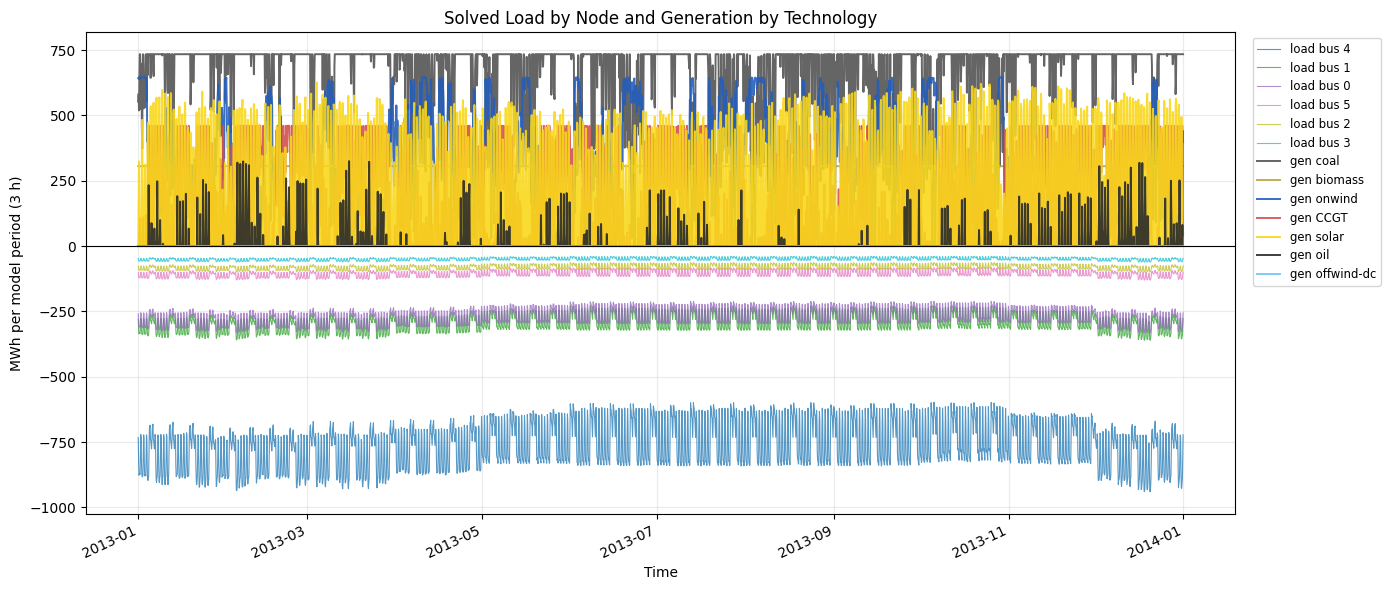

Annual generation by carrier (TWh):


,generation_TWh
carrier,
coal,1.912
biomass,0.891
onwind,0.712
CCGT,0.518
solar,0.480
oil,0.033
offwind-dc,0.000


Annual load by bus (TWh):


,load_TWh
bus,
4,2.222
1,0.852
0,0.786
5,0.308
2,0.234
3,0.145


In [2]:
# Load as negative MWh per model period; generation as positive MWh per model period.
load_mwh = n.loads_t.p_set.mul(snapshot_weights, axis=0)
load_by_bus = load_mwh.T.groupby(n.loads.bus).sum().T
load_by_bus = load_by_bus.loc[:, load_by_bus.sum().sort_values(ascending=False).index]

# Positive dispatch only. Load shedding is shown separately if it is ever used.
gen_dispatch_mwh = n.generators_t.p.clip(lower=0.0).mul(snapshot_weights, axis=0)
gen_by_carrier = gen_dispatch_mwh.T.groupby(n.generators.carrier).sum().T
gen_by_carrier = gen_by_carrier.loc[:, gen_by_carrier.sum().sort_values(ascending=False).index]
gen_by_carrier = gen_by_carrier.loc[:, gen_by_carrier.sum() > 1e-6]

node_palette = plt.cm.tab10(np.linspace(0, 1, max(len(load_by_bus.columns), 1)))
node_colors = {bus: node_palette[i % len(node_palette)] for i, bus in enumerate(load_by_bus.columns)}

fig, ax = plt.subplots(figsize=(14, 6))
for bus in load_by_bus.columns:
    ax.plot(load_by_bus.index, -load_by_bus[bus], color=node_colors[bus], lw=0.8, alpha=0.75, label=f"load bus {bus}")

for carrier in gen_by_carrier.columns:
    lw = 1.4 if carrier != "load shedding" else 1.0
    ax.plot(gen_by_carrier.index, gen_by_carrier[carrier], color=tech_color(carrier), lw=lw, alpha=0.9, label=f"gen {carrier}")

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Solved Load by Node and Generation by Technology")
ax.set_ylabel(f"MWh per model period ({period_label})")
ax.set_xlabel("Time")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize="small", ncol=1, frameon=True)
fig.autofmt_xdate(rotation=25)
plt.tight_layout()
plt.show()

annual_by_carrier = gen_by_carrier.sum().rename("generation_TWh") / 1e6
annual_load_by_bus = load_by_bus.sum().rename("load_TWh") / 1e6
print("Annual generation by carrier (TWh):")
display(styled_table(annual_by_carrier.to_frame(), "{:,.3f}"))
print("Annual load by bus (TWh):")
display(styled_table(annual_load_by_bus.to_frame(), "{:,.3f}"))


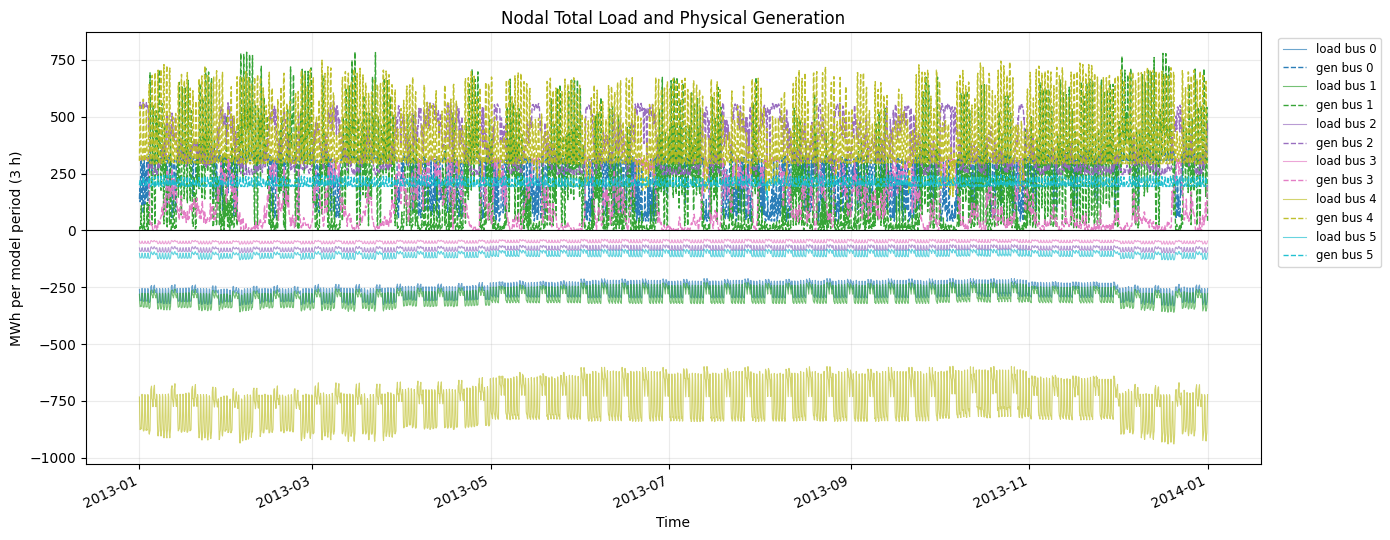

,annual_load_TWh,annual_physical_generation_TWh,generation_minus_load_TWh
bus,,,
0,0.786,0.769,-0.017
1,0.852,0.576,-0.276
2,0.234,1.070,0.836
3,0.145,0.356,0.211
4,2.222,1.169,-1.053
5,0.308,0.607,0.299


In [3]:
# Nodal physical generation versus nodal load.
physical_generators = n.generators[n.generators.carrier != "load shedding"]
physical_dispatch_mwh = gen_dispatch_mwh.loc[:, physical_generators.index]
gen_by_bus = physical_dispatch_mwh.T.groupby(physical_generators.bus).sum().T
all_buses = sorted(set(load_by_bus.columns).union(gen_by_bus.columns), key=str)
node_palette = plt.cm.tab10(np.linspace(0, 1, max(len(all_buses), 1)))
node_colors = {bus: node_palette[i % len(node_palette)] for i, bus in enumerate(all_buses)}

fig, ax = plt.subplots(figsize=(14, 5.5))
for bus in all_buses:
    if bus in load_by_bus:
        ax.plot(load_by_bus.index, -load_by_bus[bus], color=node_colors[bus], lw=0.8, alpha=0.65, label=f"load bus {bus}")
    if bus in gen_by_bus:
        ax.plot(gen_by_bus.index, gen_by_bus[bus], color=node_colors[bus], lw=1.0, alpha=0.95, linestyle="--", label=f"gen bus {bus}")

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Nodal Total Load and Physical Generation")
ax.set_ylabel(f"MWh per model period ({period_label})")
ax.set_xlabel("Time")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize="small", ncol=1, frameon=True)
fig.autofmt_xdate(rotation=25)
plt.tight_layout()
plt.show()

nodal_balance = pd.DataFrame({
    "annual_load_TWh": load_by_bus.sum() / 1e6,
    "annual_physical_generation_TWh": gen_by_bus.sum() / 1e6,
}).fillna(0.0)
nodal_balance["generation_minus_load_TWh"] = nodal_balance["annual_physical_generation_TWh"] - nodal_balance["annual_load_TWh"]
display(styled_table(nodal_balance, "{:,.3f}"))


## Built Wind and Solar Profiles

The renewable profile files are hourly pre-solve artifacts. The plotted available capacity is:

`profile[time, bus] × p_nom_max[bus]`, summed over buses.

The dashed horizontal line is the total installable `p_nom_max` from the profile file. Hourly availability is shown faintly; the darker line is the daily mean to make the year readable.


,file,status,hours,profile_buses,p_nom_max_MW,mean_available_MW,peak_available_MW,mean_capacity_factor
technology,,,,,,,,
solar,pypsa-earth/resources/mauritius-year-1/renewable_profiles/profile_solar.nc,ok,8760,8,"4,864",805,"3,303",16.56%
onwind,pypsa-earth/resources/mauritius-year-1/renewable_profiles/profile_onwind.nc,ok,8760,8,"1,815",636,"1,815",35.06%
offwind-ac,pypsa-earth/resources/mauritius-year-1/renewable_profiles/profile_offwind-ac.nc,ok,8760,7,0,0,0,nan%
offwind-dc,pypsa-earth/resources/mauritius-year-1/renewable_profiles/profile_offwind-dc.nc,ok,8760,7,"36,682","17,579","36,682",47.92%


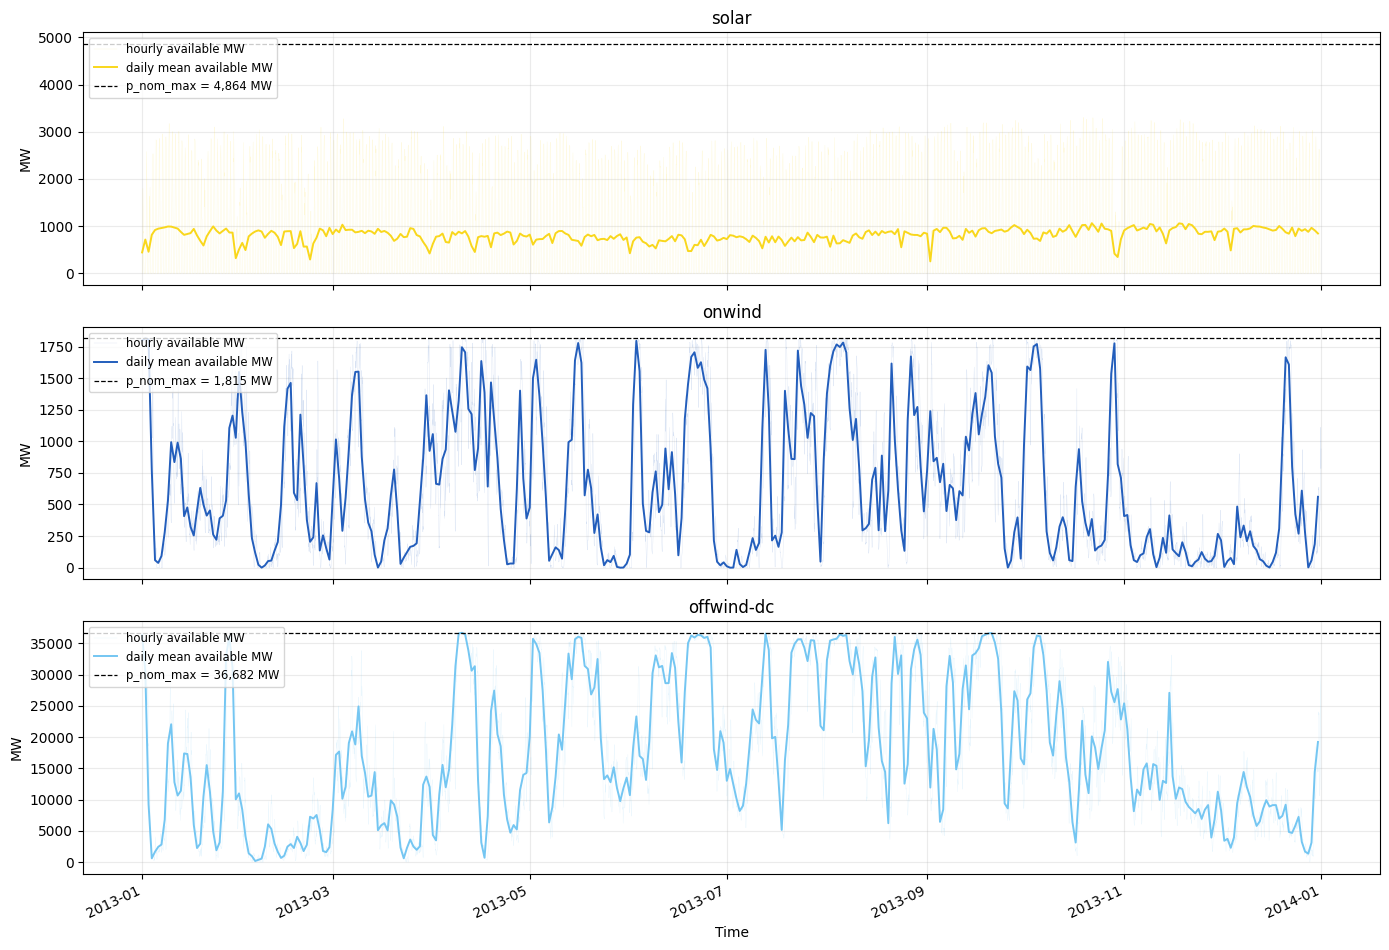

In [4]:
profile_files = {
    "solar": PROFILE_DIR / "profile_solar.nc",
    "onwind": PROFILE_DIR / "profile_onwind.nc",
    "offwind-ac": PROFILE_DIR / "profile_offwind-ac.nc",
    "offwind-dc": PROFILE_DIR / "profile_offwind-dc.nc",
}

profile_rows = []
profile_series = {}
for tech, path in profile_files.items():
    if not path.exists():
        profile_rows.append({"technology": tech, "file": str(path.relative_to(REPO_ROOT)), "status": "missing"})
        continue
    ds = xr.open_dataset(path)
    if "profile" not in ds or "p_nom_max" not in ds:
        profile_rows.append({"technology": tech, "file": str(path.relative_to(REPO_ROOT)), "status": "no profile/p_nom_max"})
        continue
    p_nom_max = ds["p_nom_max"].fillna(0.0)
    total_p_nom_max = float(p_nom_max.sum())
    available = (ds["profile"].fillna(0.0) * p_nom_max).sum("bus").to_pandas()
    available.index = pd.to_datetime(available.index)
    profile_series[tech] = {"available_MW": available, "p_nom_max_MW": total_p_nom_max}
    mean_available = float(available.mean()) if len(available) else 0.0
    profile_rows.append({
        "technology": tech,
        "file": str(path.relative_to(REPO_ROOT)),
        "status": "ok",
        "hours": len(available),
        "profile_buses": int(ds.sizes.get("bus", 0)),
        "p_nom_max_MW": total_p_nom_max,
        "mean_available_MW": mean_available,
        "peak_available_MW": float(available.max()) if len(available) else 0.0,
        "mean_capacity_factor": mean_available / total_p_nom_max if total_p_nom_max > 0 else np.nan,
    })

profile_summary = pd.DataFrame(profile_rows).set_index("technology")
display(styled_table(profile_summary, {
    "p_nom_max_MW": "{:,.0f}",
    "mean_available_MW": "{:,.0f}",
    "peak_available_MW": "{:,.0f}",
    "mean_capacity_factor": "{:.2%}",
}))

positive = {tech: data for tech, data in profile_series.items() if data["p_nom_max_MW"] > 1e-6}
if not positive:
    print("No nonzero wind/solar profile capacities found.")
else:
    fig, axes = plt.subplots(len(positive), 1, figsize=(14, 3.2 * len(positive)), sharex=True)
    if len(positive) == 1:
        axes = [axes]
    for ax, (tech, data) in zip(axes, positive.items()):
        available = data["available_MW"]
        daily = available.resample("D").mean()
        max_cap = data["p_nom_max_MW"]
        ax.plot(available.index, available, color=tech_color(tech), lw=0.25, alpha=0.18, label="hourly available MW")
        ax.plot(daily.index, daily, color=tech_color(tech), lw=1.4, label="daily mean available MW")
        ax.axhline(max_cap, color="black", lw=0.9, linestyle="--", label=f"p_nom_max = {max_cap:,.0f} MW")
        ax.set_title(tech)
        ax.set_ylabel("MW")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper left", fontsize="small", frameon=True)
    axes[-1].set_xlabel("Time")
    fig.autofmt_xdate(rotation=25)
    plt.tight_layout()
    plt.show()


## Input Data Summary for Collaborators

In [5]:
# Demand provenance from config and the run log.
load_options = config.get("load_options", {})
scenario = config.get("scenario", {})
atlite_cfg = config.get("atlite", {}).get("cutouts", {}).get("cutout-2013-era5", {})

gegis_path = "data/{ssp}/{prediction_year}/era5_{weather_year}/Africa.nc".format(
    ssp=load_options.get("ssp"),
    prediction_year=load_options.get("prediction_year"),
    weather_year=load_options.get("weather_year"),
)
if DEMAND_LOG.exists():
    log_text = DEMAND_LOG.read_text(errors="ignore")
    for line in log_text.splitlines():
        if "Merging demand data from paths" in line:
            gegis_path = line.split("paths", 1)[1].split("into", 1)[0].strip()
            break

input_rows = [
    {
        "input": "Demand source",
        "value": gegis_path,
        "notes": "GEGIS electricity demand, allocated to buses by GDP/population in build_demand_profiles.py",
    },
    {
        "input": "Demand output used by workflow",
        "value": str(DEMAND_PATH.relative_to(REPO_ROOT)) if DEMAND_PATH.exists() else "missing",
        "notes": "Hourly bus-level CSV before network simplification/clustering",
    },
    {
        "input": "Demand scenario",
        "value": f"{load_options.get('ssp')}, prediction_year={load_options.get('prediction_year')}, weather_year={load_options.get('weather_year')}, scale={load_options.get('scale')}",
        "notes": "From config load_options",
    },
    {
        "input": "Weather cutout",
        "value": "cutouts/cutout-2013-era5.nc",
        "notes": f"atlite module={atlite_cfg.get('module')}, dx={atlite_cfg.get('dx')}, dy={atlite_cfg.get('dy')}",
    },
    {
        "input": "Renewable profile files",
        "value": str(PROFILE_DIR.relative_to(REPO_ROOT)) if PROFILE_DIR.exists() else "missing",
        "notes": "Hourly NetCDF profiles with profile[time,bus] and p_nom_max[bus]",
    },
    {
        "input": "Solve temporal resolution",
        "value": ", ".join(scenario.get("opts", [])),
        "notes": f"Solved network has {len(n.snapshots)} snapshots and model period {period_label}",
    },
]
input_summary = pd.DataFrame(input_rows).set_index("input")
display(input_summary)

if DEMAND_PATH.exists():
    demand_raw = pd.read_csv(DEMAND_PATH, parse_dates=["time"])
    demand_cols = [c for c in demand_raw.columns if c != "time"]
    demand_stats = pd.Series({
        "file": str(DEMAND_PATH.relative_to(REPO_ROOT)),
        "rows_hours": len(demand_raw),
        "first_hour": str(demand_raw["time"].min()),
        "last_hour": str(demand_raw["time"].max()),
        "base_network_load_columns": len(demand_cols),
        "annual_demand_TWh_hourly_input": demand_raw[demand_cols].sum().sum() / 1e6,
        "peak_total_load_MW_hourly_input": demand_raw[demand_cols].sum(axis=1).max(),
        "annual_demand_TWh_solved_network": load_by_bus.sum().sum() / 1e6,
        "peak_total_load_MW_solved_network": n.loads_t.p_set.sum(axis=1).max(),
    })
    display(styled_table(demand_stats.to_frame("value"), "{}"))
else:
    print(f"Demand profile CSV not found: {DEMAND_PATH}")


,value,notes
input,,
Demand source,data/ssp2-2.6/2030/era5_2013/Africa.nc,"GEGIS electricity demand, allocated to buses b..."
Demand output used by workflow,pypsa-earth/resources/mauritius-year-1/demand_...,Hourly bus-level CSV before network simplifica...
Demand scenario,"ssp2-2.6, prediction_year=2030, weather_year=2...",From config load_options
Weather cutout,cutouts/cutout-2013-era5.nc,"atlite module=era5, dx=0.1, dy=0.1"
Renewable profile files,pypsa-earth/resources/mauritius-year-1/renewab...,"Hourly NetCDF profiles with profile[time,bus] ..."
Solve temporal resolution,3h,Solved network has 2920 snapshots and model pe...


,value
file,pypsa-earth/resources/mauritius-year-1/demand_profiles.csv
rows_hours,8760
first_hour,2013-01-01 00:00:00
last_hour,2013-12-31 23:00:00
base_network_load_columns,8
annual_demand_TWh_hourly_input,4.546390631345777
peak_total_load_MW_hourly_input,642.8991048117754
annual_demand_TWh_solved_network,4.546390631345778
peak_total_load_MW_solved_network,641.2262174447595


In [6]:
# Capacity limits used by the solved network.
gens = n.generators.copy()
gens["finite_p_nom_max"] = gens["p_nom_max"].replace(np.inf, np.nan)
gen_constraints = gens.groupby("carrier").agg(
    components=("carrier", "size"),
    p_nom_MW=("p_nom", "sum"),
    p_nom_min_MW=("p_nom_min", "sum"),
    p_nom_opt_MW=("p_nom_opt", "sum"),
    finite_p_nom_max_MW=("finite_p_nom_max", "sum"),
    unbounded_p_nom_max=("p_nom_max", lambda s: bool(np.isinf(s).any())),
).sort_index()
# If every row in a carrier is unbounded, the finite sum above is 0; show NaN instead.
for carrier, group in gens.groupby("carrier"):
    finite = group["finite_p_nom_max"].dropna()
    if finite.empty:
        gen_constraints.loc[carrier, "finite_p_nom_max_MW"] = np.nan

profile_pmax = profile_summary.get("p_nom_max_MW", pd.Series(dtype=float))
gen_constraints["profile_p_nom_max_MW"] = profile_pmax.reindex(gen_constraints.index)

display(styled_table(gen_constraints, {
    "p_nom_MW": "{:,.1f}",
    "p_nom_min_MW": "{:,.1f}",
    "p_nom_opt_MW": "{:,.1f}",
    "finite_p_nom_max_MW": "{:,.1f}",
    "profile_p_nom_max_MW": "{:,.1f}",
}))

other_rows = []
if not n.links.empty:
    links = n.links.copy()
    links["finite_p_nom_max"] = links["p_nom_max"].replace(np.inf, np.nan)
    for carrier, group in links.groupby("carrier"):
        finite = group["finite_p_nom_max"].dropna()
        other_rows.append({
            "component": "Link",
            "carrier": carrier,
            "components": len(group),
            "p_nom_opt_MW": group["p_nom_opt"].sum(),
            "finite_p_nom_max_MW": finite.sum() if not finite.empty else np.nan,
            "unbounded": bool(np.isinf(group["p_nom_max"]).any()),
        })
if not n.stores.empty:
    stores = n.stores.copy()
    stores["finite_e_nom_max"] = stores["e_nom_max"].replace(np.inf, np.nan)
    for carrier, group in stores.groupby("carrier"):
        finite = group["finite_e_nom_max"].dropna()
        other_rows.append({
            "component": "Store",
            "carrier": carrier,
            "components": len(group),
            "p_nom_opt_MW": np.nan,
            "finite_p_nom_max_MW": finite.sum() if not finite.empty else np.nan,
            "unbounded": bool(np.isinf(group["e_nom_max"]).any()),
        })

if other_rows:
    other_constraints = pd.DataFrame(other_rows).set_index(["component", "carrier"])
    display(styled_table(other_constraints, {
        "p_nom_opt_MW": "{:,.1f}",
        "finite_p_nom_max_MW": "{:,.1f}",
    }))
else:
    print("No link/store capacity constraints in this network.")

extendable = config.get("electricity", {}).get("extendable_carriers", {})
print("Configured extendable carriers:")
display(pd.Series({k: ", ".join(v) if isinstance(v, list) else v for k, v in extendable.items()}, name="carriers").to_frame())


,components,p_nom_MW,p_nom_min_MW,p_nom_opt_MW,finite_p_nom_max_MW,unbounded_p_nom_max,profile_p_nom_max_MW
carrier,,,,,,,
CCGT,1,109.0,109.0,153.3,nan,True,nan
biomass,4,101.8,101.8,101.8,nan,True,nan
coal,3,244.7,244.7,244.7,nan,True,nan
load shedding,12,769.5,0.0,769.5,nan,True,nan
offwind-ac,6,0.0,0.0,0.0,0.0,False,0.0
offwind-dc,6,0.0,0.0,0.0,"36,682.4",False,"36,682.4"
oil,1,387.0,387.0,387.0,nan,True,nan
onwind,6,10.6,10.6,215.3,"1,815.2",False,"1,815.2"
solar,6,125.1,125.1,329.7,"4,864.0",False,"4,864.0"


Configured extendable carriers:


,carriers
Generator,"solar, onwind, offwind-ac, offwind-dc, OCGT, CCGT"
StorageUnit,
Store,battery
Link,
